# 실험 ① 확장판 — 모델 × 방식 × 임베딩 레시피 종합 비교 (Colab)

> **근거**: `docs/감정분류_개선실험_계획서_김한솔.md` §3 · 2026-07-03
> **환경**: Colab GPU (T4 이상)

## 실험 구성
| 파트 | 내용 | 목적 |
|---|---|---|
| **1a** | KcELECTRA / KoBERT × 얼려쓰기 / 파인튜닝 (4조합) | 모델·방식 승자 |
| **1b** | 임베딩 레시피 4종 (층 × 압축) — 두 모델 모두 | "어떻게 꺼내냐"의 영향 |
| **이중 평가** | 전 조합을 작성체 테스트셋 + **채팅체 평가셋 60문장** 둘 다로 채점 | 지표 낮아도 실사용에서 나을 수 있다는 가설 검증 |
| **시각화** | 파인튜닝 전/후 t-SNE | 임베딩 공간이 감정별로 재배치되는 걸 눈으로 |

**준비물 (2개 업로드)**: `kcelectra_train_clean.jsonl` + `chat_eval_set.jsonl` (repo `data/`)
**소요**: QUICK_MODE=True 약 30분 / False 약 2시간

In [1]:
!pip install -q transformers==4.44.2 xgboost scikit-learn sentencepiece
!pip install -q 'git+https://github.com/SKTBrain/KoBERT.git#egg=kobert_tokenizer&subdirectory=kobert_hf'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 78.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
  Preparing metadata (setup.py) ... done


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import json, random
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

SEED, MAX_LEN = 42, 128
QUICK_MODE = False           # 처음엔 True로 파이프라인 검증, 본실험은 False
QUICK_N = 12000
DATA_PATH = '/content/drive/MyDrive/final-test/kcelectra_train_clean.jsonl'
CHAT_EVAL_PATH = '/content/drive/MyDrive/final-test/chat_eval_set.jsonl'

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

EMO4 = ['기쁨', '슬픔', '분노', '일반']
LAB2ID = {c: i for i, c in enumerate(EMO4)}
SIX_TO_FOUR = {'기쁨':'기쁨','슬픔':'슬픔','상처':'슬픔','분노':'분노','불안':'분노','당황':'일반'}

rows = [json.loads(l) for l in open(DATA_PATH, encoding='utf-8') if l.strip()]
df = pd.DataFrame(rows)
df['label'] = df['emotion'].map(SIX_TO_FOUR)
df = df[df['label'].isin(EMO4)].reset_index(drop=True)
if QUICK_MODE:
    df = df.groupby('label', group_keys=False).apply(
        lambda g: g.sample(min(len(g), QUICK_N // 4), random_state=SEED)).reset_index(drop=True)
df['y'] = df['label'].map(LAB2ID)
tr_texts, te_texts, tr_y, te_y = train_test_split(
    df['text'].tolist(), df['y'].values, test_size=0.2, random_state=SEED, stratify=df['y'])

# 채팅체 평가셋 — 실사용형 시험지 (학습에 절대 사용 금지)
chat = pd.DataFrame([json.loads(l) for l in open(CHAT_EVAL_PATH, encoding='utf-8') if l.strip()])
chat_texts, chat_y = chat['text'].tolist(), chat['emotion'].map(LAB2ID).values
print(f'train {len(tr_texts):,} / 작성체 test {len(te_texts):,} / 채팅체 eval {len(chat_texts)}')

device: cuda
train 46,587 / 작성체 test 11,647 / 채팅체 eval 150


## 공통 — 모델 로더 · 채점 함수

In [4]:
MODELS = {'KcELECTRA': 'beomi/KcELECTRA-base-v2022', 'KoBERT': 'skt/kobert-base-v1'}

def load_tokenizer(key):
    if key == 'KoBERT':
        from kobert_tokenizer import KoBERTTokenizer
        return KoBERTTokenizer.from_pretrained(MODELS[key])
    from transformers import AutoTokenizer
    return AutoTokenizer.from_pretrained(MODELS[key])

def load_encoder(key):
    from transformers import AutoModel
    return AutoModel.from_pretrained(MODELS[key], output_hidden_states=True).eval().to(device)

def score(y_true, pred):
    return {'acc': accuracy_score(y_true, pred), 'f1': f1_score(y_true, pred, average='macro')}

## 임베딩 — 레시피 4종을 한 번의 forward로

레시피 = (어느 층 × 어떻게 압축). 배포본 = `last4_mean`.
- `last4_mean` : 마지막 4개 층 이어붙임 + 단어 평균 (현재 배포본)
- `last1_mean` : 마지막 층만 + 단어 평균
- `last4_cls` / `last1_cls` : 평균 대신 문장 대표 토큰(CLS)만 사용

In [5]:
RECIPES = ['last4_mean', 'last1_mean', 'last4_cls', 'last1_cls']

@torch.no_grad()
def embed_all(texts, tok, enc, batch_size=64):
    out = {r: [] for r in RECIPES}
    for i in range(0, len(texts), batch_size):
        e = tok(texts[i:i+batch_size], padding=True, truncation=True,
                max_length=MAX_LEN, return_tensors='pt').to(device)
        hs = enc(**e).hidden_states
        mask = e['attention_mask'].unsqueeze(-1).float()
        pool = lambda h: (h * mask).sum(1) / mask.sum(1).clamp(min=1)
        last4 = hs[-4:]
        out['last4_mean'].append(torch.cat([pool(h) for h in last4], -1).cpu().numpy())
        out['last1_mean'].append(pool(hs[-1]).cpu().numpy())
        out['last4_cls'].append(torch.cat([h[:, 0] for h in last4], -1).cpu().numpy())
        out['last1_cls'].append(hs[-1][:, 0].cpu().numpy())
    res = {}
    for r, chunks in out.items():
        emb = np.concatenate(chunks)
        emb /= (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-9)
        res[r] = emb
    return res

## 방식 A — 얼려쓰기 + XGBoost (레시피 4종 × 이중 평가)

In [6]:
def train_xgb(Xtr, ytr):
    from xgboost import XGBClassifier
    freq = pd.Series(ytr).value_counts()
    w = np.array([len(ytr) / (len(EMO4) * freq[c]) for c in ytr])
    clf = XGBClassifier(n_estimators=600, max_depth=6, learning_rate=0.08,
                        tree_method='hist', device=device, random_state=SEED)
    clf.fit(Xtr, ytr, sample_weight=w)
    return clf

frozen_results = {}     # {(model, recipe): {'test': {...}, 'chat': {...}}}
frozen_test_emb = {}    # t-SNE용 (last4_mean)
frozen_test_pred = {}

for key in ['KcELECTRA', 'KoBERT']:
    print(f'===== {key} / 얼려쓰기 =====')
    tok, enc = load_tokenizer(key), load_encoder(key)
    Etr, Ete, Ech = embed_all(tr_texts, tok, enc), embed_all(te_texts, tok, enc), embed_all(chat_texts, tok, enc)
    del enc; torch.cuda.empty_cache()
    frozen_test_emb[key] = Ete['last4_mean']
    for r in RECIPES:
        clf = train_xgb(Etr[r], tr_y)
        p_test, p_chat = clf.predict(Ete[r]), clf.predict(Ech[r])
        frozen_results[(key, r)] = {'test': score(te_y, p_test), 'chat': score(chat_y, p_chat)}
        if r == 'last4_mean':
            frozen_test_pred[key] = p_test
        print(f"  [{r}] 작성체 F1 {frozen_results[(key, r)]['test']['f1']:.4f}"
              f" / 채팅체 F1 {frozen_results[(key, r)]['chat']['f1']:.4f}")

===== KcELECTRA / 얼려쓰기 =====


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/288 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/504 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/244 [00:00<?, ?B/s]

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'XLNetTokenizer'. 
The class this function is called from is 'KoBERTTokenizer'.
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/535 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/369M [00:00<?, ?B/s]

  [last4_mean] 작성체 F1 0.6349 / 채팅체 F1 0.4670
  [last1_mean] 작성체 F1 0.6207 / 채팅체 F1 0.4169
  [last4_cls] 작성체 F1 0.6202 / 채팅체 F1 0.4142
  [last1_cls] 작성체 F1 0.6115 / 채팅체 F1 0.3807


## 방식 B — 파인튜닝 (이중 평가 · KcELECTRA는 t-SNE용 저장)

In [7]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kw):
        super().__init__(**kw); self.class_weights = class_weights
    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        loss = torch.nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
        return (loss, outputs) if return_outputs else loss

class DS(torch.utils.data.Dataset):
    def __init__(self, texts, y, tok):
        self.enc = tok(texts, padding=True, truncation=True, max_length=MAX_LEN)
        self.y = y
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k, v in self.enc.items()}
        item['labels'] = torch.tensor(int(self.y[i])); return item

ft_results, ft_test_pred = {}, {}

def run_finetune(key, epochs=3, lr=2e-5, bs=32, save_dir=None):
    tok = load_tokenizer(key)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODELS[key], num_labels=len(EMO4)).to(device)
    freq = pd.Series(tr_y).value_counts().sort_index()
    cw = torch.tensor((len(tr_y) / (len(EMO4) * freq)).values, dtype=torch.float).to(device)
    args = TrainingArguments(output_dir=f'/tmp/ft_{key}', num_train_epochs=epochs,
        learning_rate=lr, per_device_train_batch_size=bs, per_device_eval_batch_size=64,
        fp16=(device == 'cuda'), logging_steps=100, seed=SEED,
        save_strategy='no', report_to='none')
    trainer = WeightedTrainer(class_weights=cw, model=model, args=args,
                              train_dataset=DS(tr_texts, tr_y, tok))
    trainer.train()
    p_test = trainer.predict(DS(te_texts, te_y, tok)).predictions.argmax(-1)
    p_chat = trainer.predict(DS(chat_texts, chat_y, tok)).predictions.argmax(-1)
    if save_dir:
        for p in model.parameters():
            p.data = p.data.contiguous()   # ← 저장 전 텐서 재정렬 (fp16 학습 후 필수)
        model.save_pretrained(save_dir); tok.save_pretrained(save_dir)
    del trainer, model; torch.cuda.empty_cache()
    return {'test': score(te_y, p_test), 'chat': score(chat_y, p_chat)}, p_test

for key in ['KcELECTRA', 'KoBERT']:
    print(f'===== {key} / 파인튜닝 =====')
    save = '/tmp/ft_final_kcelectra' if key == 'KcELECTRA' else None
    ft_results[key], ft_test_pred[key] = run_finetune(key, save_dir=save)
    print(f"  작성체 F1 {ft_results[key]['test']['f1']:.4f} / 채팅체 F1 {ft_results[key]['chat']['f1']:.4f}")

===== KcELECTRA / 파인튜닝 =====


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at beomi/KcELECTRA-base-v2022 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
100,1.198400
200,0.993300
300,0.871500
400,0.830800
500,0.816000
600,0.768500
700,0.760500
800,0.750200
900,0.774600
1000,0.747500


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'XLNetTokenizer'. 
The class this function is called from is 'KoBERTTokenizer'.


  작성체 F1 0.7096 / 채팅체 F1 0.5484
===== KoBERT / 파인튜닝 =====


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at skt/kobert-base-v1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
100,1.183800
200,0.997500
300,0.894200
400,0.870400
500,0.840100
600,0.802500
700,0.788000
800,0.809900
900,0.799200
1000,0.804600


  작성체 F1 0.6903 / 채팅체 F1 0.4576


## 종합 결과표 — 작성체 vs 채팅체 (핵심 질문: 순위가 갈리는가?)

In [8]:
rows = []
for (m, r), v in frozen_results.items():
    rows.append({'조합': f'{m} · 얼려쓰기({r})',
                 '작성체 Acc': v['test']['acc'], '작성체 F1': v['test']['f1'],
                 '채팅체 Acc': v['chat']['acc'], '채팅체 F1': v['chat']['f1']})
for m, v in ft_results.items():
    rows.append({'조합': f'{m} · 파인튜닝',
                 '작성체 Acc': v['test']['acc'], '작성체 F1': v['test']['f1'],
                 '채팅체 Acc': v['chat']['acc'], '채팅체 F1': v['chat']['f1']})
tbl = pd.DataFrame(rows).set_index('조합').round(4)
display(tbl.sort_values('작성체 F1', ascending=False))

w_test = tbl['작성체 F1'].idxmax(); w_chat = tbl['채팅체 F1'].idxmax()
print(f'작성체 승자: {w_test}')
print(f'채팅체 승자: {w_chat}')
if w_test != w_chat:
    print('→ ⚠ 순위 역전! 실사용 입력 기준(채팅체)을 우선해 선택하되, 채팅체 셋이 60문장뿐이므로')
    print('   문장을 늘려 재확인 후 확정할 것.')
else:
    print('→ 두 시험지 모두 같은 승자 — 안심하고 채택.')

with open('exp1_results.json', 'w', encoding='utf-8') as f:
    json.dump(tbl.to_dict('index'), f, ensure_ascii=False, indent=2)
print('exp1_results.json 저장 → repo 커밋 + 계획서 §3 기입')

,작성체 Acc,작성체 F1,채팅체 Acc,채팅체 F1
조합,,,,
KcELECTRA · 파인튜닝,0.6911,0.7096,0.5867,0.5484
KoBERT · 파인튜닝,0.6705,0.6903,0.5067,0.4576
KcELECTRA · 얼려쓰기(last4_mean),0.6463,0.6598,0.5800,0.5217
KoBERT · 얼려쓰기(last4_mean),0.6318,0.6349,0.5133,0.4670
KcELECTRA · 얼려쓰기(last4_cls),0.6238,0.6342,0.5800,0.5054
KoBERT · 얼려쓰기(last1_mean),0.6150,0.6207,0.4533,0.4169
KoBERT · 얼려쓰기(last4_cls),0.6156,0.6202,0.4400,0.4142
KoBERT · 얼려쓰기(last1_cls),0.6052,0.6115,0.4133,0.3807
KcELECTRA · 얼려쓰기(last1_mean),0.5893,0.5952,0.5067,0.4530


작성체 승자: KcELECTRA · 파인튜닝
채팅체 승자: KcELECTRA · 파인튜닝
→ 두 시험지 모두 같은 승자 — 안심하고 채택.
exp1_results.json 저장 → repo 커밋 + 계획서 §3 기입


## 승자 클래스별 성능 (작성체 기준)

In [9]:
best_ft = max(ft_results, key=lambda k: ft_results[k]['test']['f1'])
print(f'[파인튜닝 최고: {best_ft}]')
print(classification_report(te_y, ft_test_pred[best_ft], target_names=EMO4, digits=3))
best_fz = max(frozen_test_pred, key=lambda k: frozen_results[(k, 'last4_mean')]['test']['f1'])
print(f'[얼려쓰기 최고: {best_fz} (last4_mean)]')
print(classification_report(te_y, frozen_test_pred[best_fz], target_names=EMO4, digits=3))

[파인튜닝 최고: KcELECTRA]
              precision    recall  f1-score   support

          기쁨      0.877     0.915     0.896      1467
          슬픔      0.670     0.712     0.690      4052
          분노      0.717     0.631     0.671      4168
          일반      0.556     0.609     0.582      1960

    accuracy                          0.691     11647
   macro avg      0.705     0.717     0.710     11647
weighted avg      0.694     0.691     0.691     11647

[얼려쓰기 최고: KcELECTRA (last4_mean)]
              precision    recall  f1-score   support

          기쁨      0.897     0.864     0.880      1467
          슬픔      0.615     0.657     0.635      4052
          분노      0.618     0.670     0.643      4168
          일반      0.579     0.410     0.480      1960

    accuracy                          0.646     11647
   macro avg      0.677     0.650     0.660     11647
weighted avg      0.646     0.646     0.643     11647



## t-SNE — "숫자 좌표"가 감정 공간으로 재배치되는 것을 눈으로

왼쪽: 파인튜닝 **전**(얼려쓰기 임베딩) — 색이 섞여 있을수록 XGBoost가 고생한 것.
오른쪽: 파인튜닝 **후** — 4색이 갈라질수록 임베딩 자체가 감정을 학습한 것.

/tmp/ipykernel_1883/3699976634.py:42: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1883/3699976634.py:42: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1883/3699976634.py:42: UserWarning: Glyph 53916 (\N{HANGUL SYLLABLE TYU}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1883/3699976634.py:42: UserWarning: Glyph 45789 (\N{HANGUL SYLLABLE NING}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1883/3699976634.py:42: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1883/3699976634.py:42: UserWarning: Glyph 50620 (\N{HANGUL SYLLABLE EOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_1883/3699976634.py:42: UserWarning: Glyph 47140 (

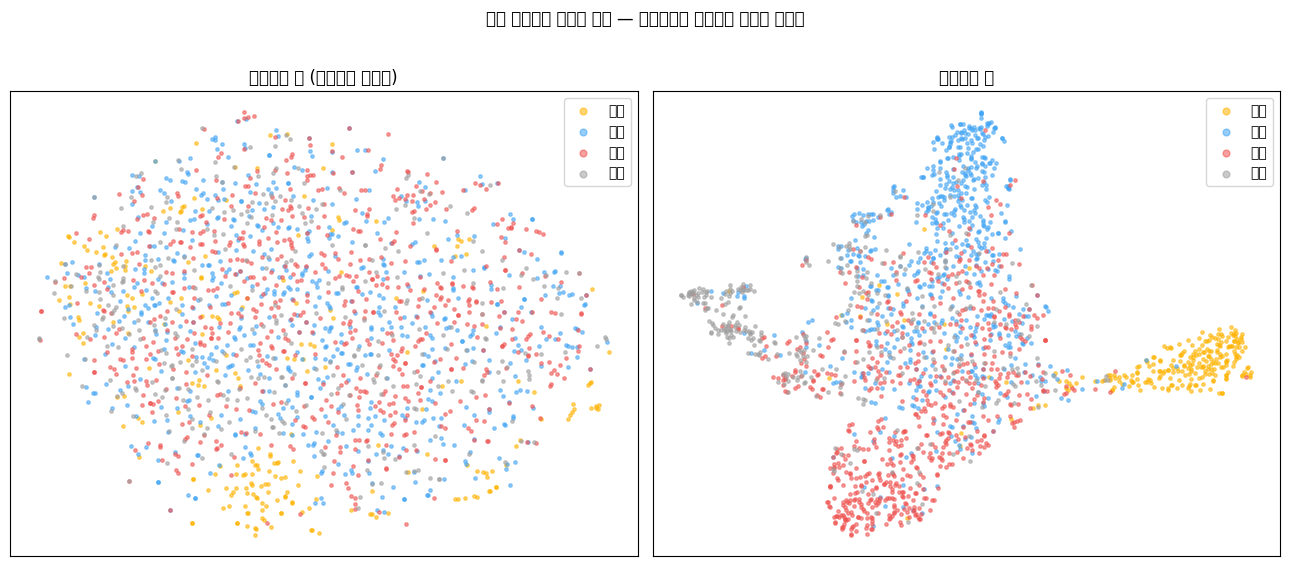

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
for f in fm.fontManager.ttflist:
    if 'Nanum' in f.name or 'CJK' in f.name:
        plt.rcParams['font.family'] = f.name; break
plt.rcParams['axes.unicode_minus'] = False

N_VIS = min(2000, len(te_texts))
idx = np.random.RandomState(SEED).choice(len(te_texts), N_VIS, replace=False)
vis_texts = [te_texts[i] for i in idx]; vis_y = te_y[idx]

# 파인튜닝 후 임베딩 (저장해둔 KcELECTRA 파인튜닝 모델의 마지막 층)
from transformers import AutoModel, AutoTokenizer
ft_tok = AutoTokenizer.from_pretrained('/tmp/ft_final_kcelectra')
ft_enc = AutoModel.from_pretrained('/tmp/ft_final_kcelectra', output_hidden_states=True).eval().to(device)

@torch.no_grad()
def embed_last_mean(texts, tok, enc, bs=64):
    embs = []
    for i in range(0, len(texts), bs):
        e = tok(texts[i:i+bs], padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt').to(device)
        hs = enc(**e).hidden_states[-1]
        mask = e['attention_mask'].unsqueeze(-1).float()
        embs.append(((hs * mask).sum(1) / mask.sum(1).clamp(min=1)).cpu().numpy())
    return np.concatenate(embs)

before = frozen_test_emb['KcELECTRA'][idx]
after = embed_last_mean(vis_texts, ft_tok, ft_enc)
del ft_enc; torch.cuda.empty_cache()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colors = ['#FFB300', '#42A5F5', '#EF5350', '#9E9E9E']
for ax, emb, title in [(axes[0], before, '파인튜닝 전 (얼려쓰기 임베딩)'),
                       (axes[1], after, '파인튜닝 후')]:
    z = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(emb)
    for c in range(4):
        m = vis_y == c
        ax.scatter(z[m, 0], z[m, 1], s=6, alpha=0.55, color=colors[c], label=EMO4[c])
    ax.set_title(title); ax.legend(markerscale=2); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('같은 문장들의 임베딩 좌표 — 파인튜닝이 감정별로 공간을 재배치', y=1.02)
plt.tight_layout(); plt.show()

## 해석 가이드

1. **QUICK_MODE 결과는 방향성** — 본실험(False)으로 확정.
2. **채택 기준**: 작성체·채팅체 순위가 같으면 그대로, 갈리면 **채팅체 우선** (단, 60문장 셋을 팀 검수·증량 후 재확인).
3. 레시피 비교(1b)에서 last4_mean이 밀리면 배포본 임베딩 레시피도 교체 대상.
4. 파인튜닝이 이기면 → `ai/emotion/emotion_model.py`를 분류 헤드 방식으로 전환 (XGBoost 단계 제거).
5. 다음: **실험 ② 데이터 추가 ablation** (계획서 §4) — 승자 조합 고정, +웰니스/+음성전사/+KOTE.
6. 결과물 커밋: `exp1_results.json` + 계획서 §3 표 기입 + t-SNE 그림은 발표 자료행.